# 3. Pretrained Models (Transfer Learning)

**Goal:** reuse CNNs trained on ImageNet as feature extractors and compare them with the simple CNNs.

**Setup for every model:**
- Base model loaded with ImageNet weights, top removed, **frozen** (only the new head is trained).
- Same augmentation, Adam optimiser, loss, early stopping and seed as notebook 2.
- **Added head:** `GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.3) → Dense(73, softmax)`.
  The extra `Dense(256)` layer lets the model combine ImageNet features for our 73 objects. Set `dense_units=None` to train without it and compare.

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.applications import MobileNetV2, ResNet50V2, EfficientNetB0

SEED = 42
EPOCHS = 30
BATCH = 32
PATIENCE = 5
keras.utils.set_random_seed(SEED)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 2})
TRAIN_C, VAL_C, TEST_C = '#2a78d6', '#eb6834', '#1baf7a'

In [2]:
data = np.load('data/dataset.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
CLASSES = data['classes']
NUM_CLASSES = len(CLASSES)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Classes:', NUM_CLASSES)

Train: (5120, 224, 224, 3) | Val: (1097, 224, 224, 3) | Classes: 73


## 3.1 Generic Model Function

In [3]:
def augmentation():
    # Same pipeline as notebook 1. Active only during training (model.fit).
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomPerspective(factor=0.5, scale=0.2),   # warp
        layers.RandomGaussianBlur(factor=0.5, sigma=1.0),  # blur
    ], name='augmentation')


def build_pretrained(name, base_fn, scale_to_minus1, dense_units=256, optimizer='adam'):
    keras.utils.set_random_seed(SEED)
    base = base_fn(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base.trainable = False                       # freeze ImageNet weights

    inputs = keras.Input(shape=(224, 224, 3))
    x = augmentation()(inputs)
    if scale_to_minus1:                          # input scaling expected by the base model
        x = layers.Rescaling(1. / 127.5, offset=-1)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if dense_units:                              # added layer
        x = layers.Dense(dense_units, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
results, histories = {}, {}

def count_layers(model):
    return sum(count_layers(l) if isinstance(l, keras.Model) else 1 for l in model.layers)

def train(model, architecture):
    early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                                               restore_best_weights=True)
    start = time.time()
    h = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS,
                  batch_size=BATCH, shuffle=True, callbacks=[early_stop], verbose=2)
    train_time = time.time() - start

    model.save(f'models/{model.name}.keras')
    with open(f'results/history_{model.name}.json', 'w') as f:
        json.dump(h.history, f)

    best = int(np.argmax(h.history['val_accuracy']))
    histories[model.name] = h.history
    results[model.name] = {
        'Model': model.name, 'Architecture': architecture,
        'Layers': count_layers(model), 'Params': model.count_params(),
        'Trainable Params': int(sum(np.prod(w.shape) for w in model.trainable_weights)),
        'Epochs Run': len(h.history['accuracy']), 'Best Epoch': best + 1,
        'Train Acc': round(h.history['accuracy'][best], 4),
        'Val Acc': round(h.history['val_accuracy'][best], 4),
        'Train Time (s)': round(train_time),
    }
    print(results[model.name])

## 3.2 MobileNetV2
Lightweight network (depthwise separable convolutions), built for mobile devices. ~2.3M base params. Expects inputs in [-1, 1].

In [5]:
mobilenet = build_pretrained('MobileNetV2', MobileNetV2, scale_to_minus1=True)
mobilenet.summary()
train(mobilenet, 'MobileNetV2 (frozen) + Dense 256')

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 73)             │        18,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,604,681 (9.94 MB)

 Trainable params: 346,697 (1.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
160/160 - 31s - 195ms/step - accuracy: 0.4094 - loss: 2.6318 - val_accuracy: 0.7575 - val_loss: 1.1853
Epoch 2/30
160/160 - 28s - 177ms/step - accuracy: 0.7383 - loss: 1.0943 - val_accuracy: 0.8077 - val_loss: 0.8462
Epoch 3/30
160/160 - 29s - 180ms/step - accuracy: 0.8045 - loss: 0.7715 - val_accuracy: 0.8377 - val_loss: 0.7174
Epoch 4/30
160/160 - 29s - 181ms/step - accuracy: 0.8432 - loss: 0.5934 - val_accuracy: 0.8587 - val_loss: 0.6456
Epoch 5/30
160/160 - 29s - 183ms/step - accuracy: 0.8705 - loss: 0.5058 - val_accuracy: 0.8678 - val_loss: 0.6087
Epoch 6/30
160/160 - 29s - 181ms/step - accuracy: 0.8949 - loss: 0.4107 - val_accuracy: 0.8696 - val_loss: 0.5987
Epoch 7/30
160/160 - 29s - 180ms/step - accuracy: 0.9021 - loss: 0.3647 - val_accuracy: 0.8687 - val_loss: 0.6079
Epoch 8/30
160/160 - 29s - 184ms/step - accuracy: 0.9080 - loss: 0.3407 - val_accuracy: 0.8751 - val_loss: 0.5834
Epoch 9/30
160/160 - 29s - 181ms/step - accuracy: 0.9133 - loss: 0.3006 - val_accuracy: 

## 3.3 ResNet50V2
50-layer residual network; skip connections allow very deep models to train. ~23.6M base params. Expects inputs in [-1, 1].

In [6]:
resnet = build_pretrained('ResNet50V2', ResNet50V2, scale_to_minus1=True)
resnet.summary()
train(resnet, 'ResNet50V2 (frozen) + Dense 256')

Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 73)             │        18,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,108,105 (91.97 MB)

 Trainable params: 543,305 (2.07 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/30
160/160 - 90s - 563ms/step - accuracy: 0.5021 - loss: 2.1591 - val_accuracy: 0.7776 - val_loss: 0.9484
Epoch 2/30
160/160 - 86s - 537ms/step - accuracy: 0.7664 - loss: 0.9120 - val_accuracy: 0.8295 - val_loss: 0.7247
Epoch 3/30
160/160 - 86s - 539ms/step - accuracy: 0.8404 - loss: 0.6182 - val_accuracy: 0.8532 - val_loss: 0.6375
Epoch 4/30
160/160 - 88s - 553ms/step - accuracy: 0.8713 - loss: 0.4858 - val_accuracy: 0.8624 - val_loss: 0.5924
Epoch 5/30
160/160 - 88s - 550ms/step - accuracy: 0.8898 - loss: 0.3979 - val_accuracy: 0.8642 - val_loss: 0.5986
Epoch 6/30
160/160 - 90s - 564ms/step - accuracy: 0.9096 - loss: 0.3231 - val_accuracy: 0.8788 - val_loss: 0.5861
Epoch 7/30
160/160 - 93s - 583ms/step - accuracy: 0.9266 - loss: 0.2716 - val_accuracy: 0.8879 - val_loss: 0.5665
Epoch 8/30
160/160 - 89s - 555ms/step - accuracy: 0.9322 - loss: 0.2486 - val_accuracy: 0.8724 - val_loss: 0.6038
Epoch 9/30
160/160 - 88s - 552ms/step - accuracy: 0.9393 - loss: 0.2143 - val_accuracy: 

## 3.4 EfficientNetB0
Scales depth, width and resolution together for high accuracy per parameter. ~4.0M base params. Takes raw 0–255 inputs (scaling is built in).

In [7]:
effnet = build_pretrained('EfficientNetB0', EfficientNetB0, scale_to_minus1=False)
effnet.summary()
train(effnet, 'EfficientNetB0 (frozen) + Dense 256')

Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 73)             │        18,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,396,268 (16.77 MB)

 Trainable params: 346,697 (1.32 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/30
160/160 - 48s - 300ms/step - accuracy: 0.5432 - loss: 2.1316 - val_accuracy: 0.8323 - val_loss: 0.8320
Epoch 2/30
160/160 - 46s - 287ms/step - accuracy: 0.8258 - loss: 0.7534 - val_accuracy: 0.8769 - val_loss: 0.5765
Epoch 3/30
160/160 - 45s - 279ms/step - accuracy: 0.8912 - loss: 0.4723 - val_accuracy: 0.8970 - val_loss: 0.4757
Epoch 4/30
160/160 - 43s - 267ms/step - accuracy: 0.9164 - loss: 0.3399 - val_accuracy: 0.9015 - val_loss: 0.4335
Epoch 5/30
160/160 - 43s - 266ms/step - accuracy: 0.9285 - loss: 0.2930 - val_accuracy: 0.9061 - val_loss: 0.4230
Epoch 6/30
160/160 - 43s - 267ms/step - accuracy: 0.9453 - loss: 0.2247 - val_accuracy: 0.9152 - val_loss: 0.3941
Epoch 7/30
160/160 - 43s - 267ms/step - accuracy: 0.9574 - loss: 0.1754 - val_accuracy: 0.9107 - val_loss: 0.3860
Epoch 8/30
160/160 - 42s - 265ms/step - accuracy: 0.9611 - loss: 0.1565 - val_accuracy: 0.9143 - val_loss: 0.3737
Epoch 9/30
160/160 - 42s - 263ms/step - accuracy: 0.9658 - loss: 0.1382 - val_accuracy: 

## 3.5 Results

In [8]:
pretrained_df = pd.DataFrame(results.values())
pretrained_df.to_csv('results/pretrained_results.csv', index=False)
pretrained_df

,Model,Architecture,Layers,Params,Trainable Params,Epochs Run,Best Epoch,Train Acc,Val Acc,Train Time (s)
0,MobileNetV2,MobileNetV2 (frozen) + Dense 256,165,2604681,346697,19,14,0.9422,0.8833,553
1,ResNet50V2,ResNet50V2 (frozen) + Dense 256,201,24108105,543305,16,11,0.9512,0.8924,1430
2,EfficientNetB0,EfficientNetB0 (frozen) + Dense 256,248,4396268,346697,11,6,0.9453,0.9152,480


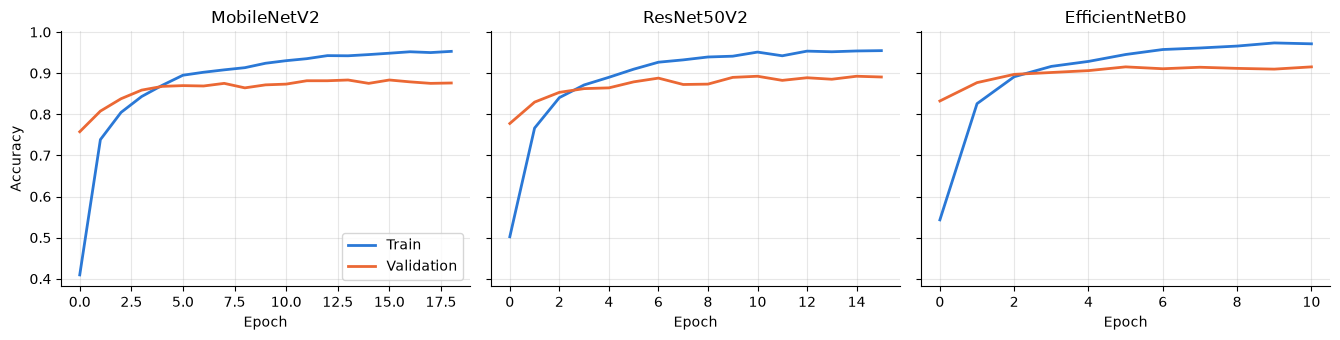

In [9]:
def plot_curves(histories):
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 3.5), sharey=True, squeeze=False)
    for ax, (name, h) in zip(axes[0], histories.items()):
        ax.plot(h['accuracy'], color=TRAIN_C, label='Train')
        ax.plot(h['val_accuracy'], color=VAL_C, label='Validation')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
    axes[0][0].set_ylabel('Accuracy')
    axes[0][0].legend()
    plt.tight_layout()
    plt.show()

plot_curves(histories)